Configuration
-------------
Event             : GW170817
Detector          : H1
Catalog event GPS : 1187008882.4
Segment start GPS : 1187008754
Segment end GPS   : 1187009010
Duration          : 256 s
Sample rate       : 4096 Hz
f_low             : 30.0 Hz
Template masses   : 1.36, 1.17 Msun

Downloaded real detector data
-----------------------------
strain.t0         : 1187008754.0
strain end        : 1187009010.0
Number of samples : 1048576
Sample spacing dt : 0.000244140625 s

Constructed PyCBC data and PSD
------------------------------
data.start_time   : 1187008754.0
data.end_time     : 1187009010.0
PSD length        : 524289
PSD delta_f       : 0.00390625 Hz

Generated theoretical template
------------------------------
hp length         : 266244
hp duration       : 65.0009765625 s
hp.start_time     : -65.000976562 s
Template time convention: hp runs from negative time to ~0 s,
with t=0 the template's nominal coalescence time.

Placed template on detector GPS grid
-------------

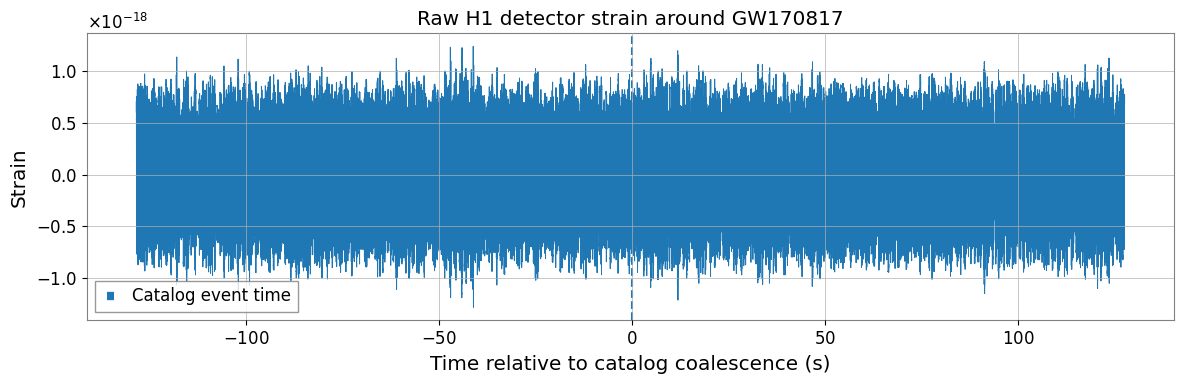

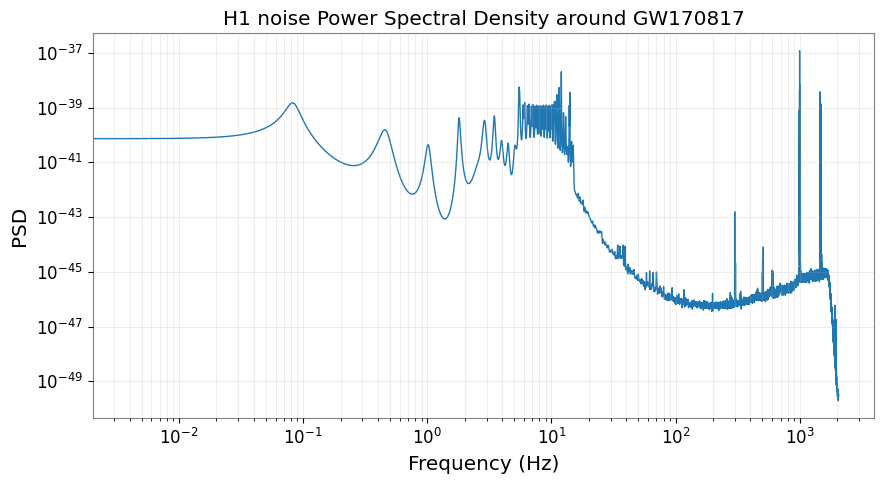

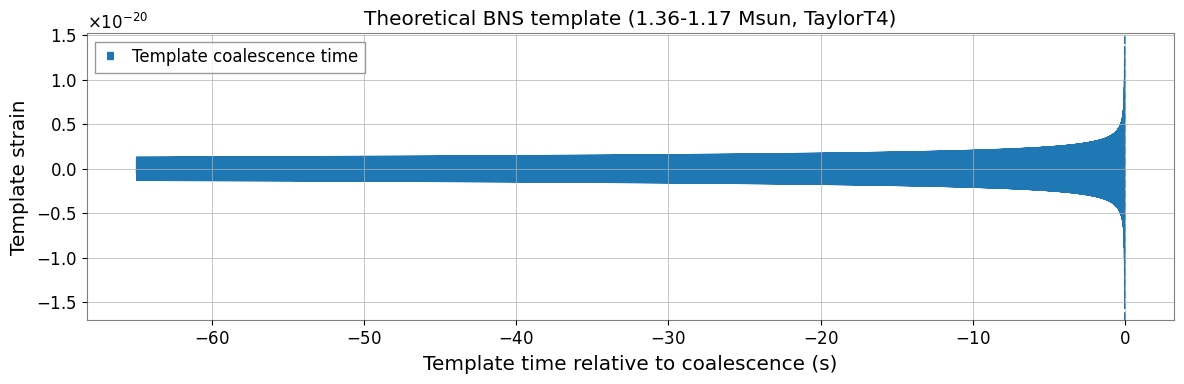

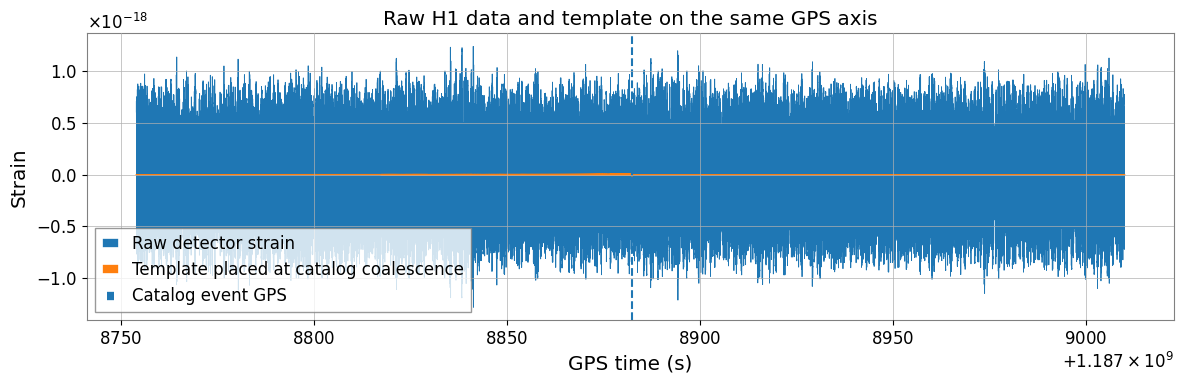

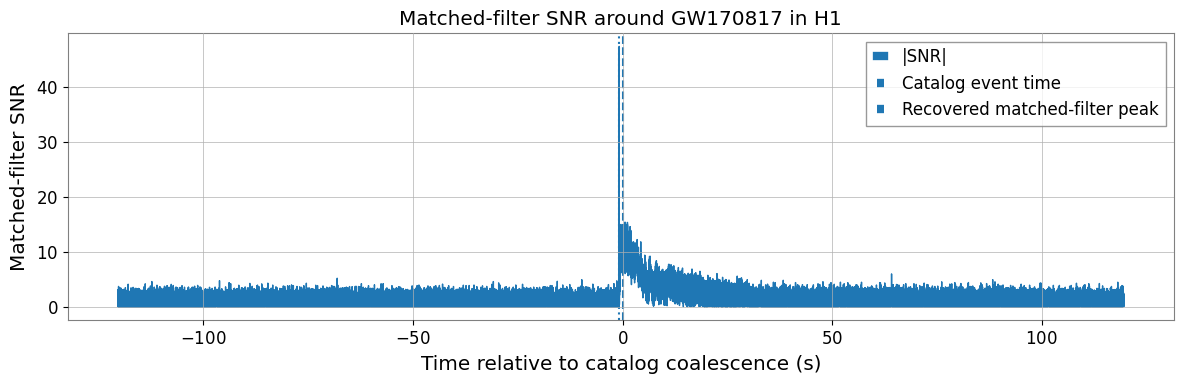

Final summary
-------------
Recovered |SNR| = 47.482
Recovered timing offset = -0.798438 s
This is the earlier manual-GPS-template branch that gave the strong recovery.


In [3]:
# ============================================================
# GW170817 NOTEBOOK
# EARLIER "HIGH-SNR / ~ -0.8 s OFFSET" BRANCH
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from gwpy.timeseries import TimeSeries
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.types import TimeSeries as PyCBCTimeSeries

# ------------------------------------------------------------
# 1. EVENT / ANALYSIS CONFIGURATION
# ------------------------------------------------------------
event_name = "GW170817"
detector = "H1"

# Published coalescence time:
# 2017-08-17 12:41:04.4 UTC
# GPS time used by LIGO/PyCBC:
event_gps = 1187008882.4

# Real detector-data segment
duration = 256
sample_rate = 4096
f_low = 30.0

# Representative low-spin GW170817-like masses

mass1 = 1.36
mass2 = 1.17

start_time = int(event_gps - duration / 2)
end_time = int(event_gps + duration / 2)

print("Configuration")
print("-------------")
print(f"Event             : {event_name}")
print(f"Detector          : {detector}")
print(f"Catalog event GPS : {event_gps}")
print(f"Segment start GPS : {start_time}")
print(f"Segment end GPS   : {end_time}")
print(f"Duration          : {duration} s")
print(f"Sample rate       : {sample_rate} Hz")
print(f"f_low             : {f_low} Hz")
print(f"Template masses   : {mass1}, {mass2} Msun")
print()

# ------------------------------------------------------------
# 2. DOWNLOAD REAL DETECTOR DATA
# ------------------------------------------------------------
# strain = REAL Hanford detector strain from GWOSC
strain = TimeSeries.fetch_open_data(
    detector,
    start_time,
    end_time,
    sample_rate=sample_rate
)

print("Downloaded real detector data")
print("-----------------------------")
print(f"strain.t0         : {strain.t0.value}")
print(f"strain end        : {float(strain.span[1])}")
print(f"Number of samples : {len(strain)}")
print(f"Sample spacing dt : {strain.dt.value} s")
print()

# Absolute and relative time axes for the REAL detector data
strain_times_gps = strain.times.value
strain_times_rel = strain_times_gps - event_gps

# ------------------------------------------------------------
# 3. CONVERT REAL DATA TO PYCBC FORMAT AND ESTIMATE PSD
# ------------------------------------------------------------
# data = same REAL detector data, now in PyCBC format
# with explicit GPS epoch preserved
data = PyCBCTimeSeries(
    strain.value,
    delta_t=strain.dt.value,
    epoch=float(strain.t0.value)
)

psd = data.psd(8)
psd = interpolate(psd, data.delta_f)
psd = inverse_spectrum_truncation(psd, int(4 * sample_rate))

print("Constructed PyCBC data and PSD")
print("------------------------------")
print(f"data.start_time   : {float(data.start_time)}")
print(f"data.end_time     : {float(data.end_time)}")
print(f"PSD length        : {len(psd)}")
print(f"PSD delta_f       : {float(psd.delta_f)} Hz")
print()

# ------------------------------------------------------------
# 4. GENERATE THEORETICAL TIME-DOMAIN BNS TEMPLATE
# ------------------------------------------------------------
# hp, hc are THEORETICAL waveform polarizations from general relativity.
# These are not detector data.
#
# Time convention of hp:
#   hp.sample_times runs from a negative start time up to ~0 s
#   t = 0 is the template's nominal coalescence time
hp, hc = get_td_waveform(
    approximant="TaylorT4",
    mass1=mass1,
    mass2=mass2,
    delta_t=1.0 / sample_rate,
    f_lower=f_low
)

template_internal_times = hp.sample_times.numpy()
template_internal_values = hp.numpy()

print("Generated theoretical template")
print("------------------------------")
print(f"hp length         : {len(hp)}")
print(f"hp duration       : {len(hp) * float(hp.delta_t)} s")
print(f"hp.start_time     : {float(hp.start_time)} s")
print("Template time convention: hp runs from negative time to ~0 s,")
print("with t=0 the template's nominal coalescence time.")
print()

# ------------------------------------------------------------
# 5. PLACE TEMPLATE ON THE DETECTOR GPS GRID
# ------------------------------------------------------------
#
# We explicitly place the theoretical template onto the same absolute
# GPS time axis as the detector data by declaring:
#
#   template_times_gps = event_gps + hp.sample_times
#
# meaning:
#   - the template coalescence is placed exactly at event_gps
#   - the inspiral occupies times before event_gps
#
# Then we embed that nonzero template support into a zero array defined
# on the detector data sample grid.
#
# This produces:
#   template_on_data_grid
# which is zero outside the intrinsic template support.

template_times_gps = event_gps + template_internal_times
template_values = template_internal_values

template_on_data_grid = np.zeros_like(strain.value)

data_start_gps = float(strain.t0.value)
dt = float(strain.dt.value)

template_start_gps = float(template_times_gps[0])
template_end_gps = float(template_times_gps[-1])

start_index = int(round((template_start_gps - data_start_gps) / dt))
end_index = start_index + len(template_values)

template_on_data_grid[start_index:end_index] = template_values

print("Placed template on detector GPS grid")
print("------------------------------------")
print(f"Template start GPS   : {template_start_gps}")
print(f"Template end GPS     : {template_end_gps}")
print(f"Template start index : {start_index}")
print(f"Template end index   : {end_index}")
print("Outside this interval, the template is exactly zero.")
print()

# ------------------------------------------------------------
# 6. CONSTRUCT MATCHED-FILTER TEMPLATE OBJECT
# ------------------------------------------------------------
# template = the THEORETICAL waveform h(t), now sampled on the exact same
# GPS time grid as the REAL detector data.
#
# Important:
# - template and data have identical length
# - template and data have identical sample spacing
# - template and data have the same absolute GPS epoch
#
# This is the branch that earlier gave the ~38–47 SNR result.
template = PyCBCTimeSeries(
    template_on_data_grid,
    delta_t=float(strain.dt.value),
    epoch=float(strain.t0.value)
)

print("Prepared template for matched filtering")
print("--------------------------------------")
print(f"template length   : {len(template)}")
print(f"data length       : {len(data)}")
print(f"template start GPS: {float(template.start_time)}")
print(f"data start GPS    : {float(data.start_time)}")
print()

# ------------------------------------------------------------
# 7. COMPUTE MATCHED-FILTER SNR
# ------------------------------------------------------------
# We now compare:
#   template = theoretical waveform h(t), on the detector GPS grid
#   data     = real detector strain s(t)
#   psd      = noise model S_n(f) estimated from the real data
snr = matched_filter(
    template,
    data,
    psd=psd,
    low_frequency_cutoff=f_low
)

crop_seconds = 8
snr = snr.crop(crop_seconds, crop_seconds)

snr_values = np.abs(snr.numpy())
peak_index = np.argmax(snr_values)
peak_snr = snr_values[peak_index]
peak_time_gps = float(snr.sample_times[peak_index])
peak_offset = peak_time_gps - event_gps

print("Matched filter result")
print("---------------------")
print(f"Peak |SNR|        : {peak_snr:.6f}")
print(f"Recovered peak GPS: {peak_time_gps:.6f}")
print(f"Catalog GPS       : {event_gps:.6f}")
print(f"Timing offset     : {peak_offset:.6f} s")
print()

# Relative SNR time axis
snr_times_rel = snr.sample_times.numpy() - event_gps

# ------------------------------------------------------------
# 8. PLOTS
# ------------------------------------------------------------

# Raw detector strain
plt.figure(figsize=(12, 4))
plt.plot(strain_times_rel, strain.value, linewidth=0.7)
plt.axvline(0.0, linestyle="--", label="Catalog event time")
plt.xlabel("Time relative to catalog coalescence (s)")
plt.ylabel("Strain")
plt.title(f"Raw {detector} detector strain around {event_name}")
plt.legend()
plt.tight_layout()
plt.show()

# PSD
frequencies_hz = psd.sample_frequencies.numpy()
psd_values = psd.numpy()

plt.figure(figsize=(9, 5))
plt.loglog(frequencies_hz, psd_values, linewidth=1.0)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title(f"{detector} noise Power Spectral Density around {event_name}")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Theoretical template in its own intrinsic time coordinate
plt.figure(figsize=(12, 4))
plt.plot(template_internal_times, template_internal_values, linewidth=0.8)
plt.axvline(0.0, linestyle="--", label="Template coalescence time")
plt.xlabel("Template time relative to coalescence (s)")
plt.ylabel("Template strain")
plt.title(f"Theoretical BNS template ({mass1}-{mass2} Msun, TaylorT4)")
plt.legend()
plt.tight_layout()
plt.show()

# Template placed on detector GPS grid
plt.figure(figsize=(12, 4))
plt.plot(strain_times_gps, strain.value, linewidth=0.6, label="Raw detector strain")
plt.plot(strain_times_gps, template_on_data_grid, linewidth=1.0, label="Template placed at catalog coalescence")
plt.axvline(event_gps, linestyle="--", label="Catalog event GPS")
plt.xlabel("GPS time (s)")
plt.ylabel("Strain")
plt.title(f"Raw {detector} data and template on the same GPS axis")
plt.legend()
plt.tight_layout()
plt.show()

# SNR
plt.figure(figsize=(12, 4))
plt.plot(snr_times_rel, snr_values, linewidth=1.0, label="|SNR|")
plt.axvline(0.0, linestyle="--", label="Catalog event time")
plt.axvline(peak_offset, linestyle=":", label="Recovered matched-filter peak")
plt.xlabel("Time relative to catalog coalescence (s)")
plt.ylabel("Matched-filter SNR")
plt.title(f"Matched-filter SNR around {event_name} in {detector}")
plt.legend()
plt.tight_layout()
plt.show()

print("Final summary")
print("-------------")
print(f"Recovered |SNR| = {peak_snr:.3f}")
print(f"Recovered timing offset = {peak_offset:.6f} s")
print("This is the earlier manual-GPS-template branch that gave the strong recovery.")